# 05 — Recommendation System

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mohamed-Al-Saudi/EnergySavvy-AI-Project/blob/main/notebooks/05_recommendation_system.ipynb)


**Goal:** Convert measured patterns and model outputs into explainable recommendations.

**Input:**
- `data/household_power/processed/household_power_hourly.parquet`
- `data/household_power/processed/household_power_daily.csv`
- `reports/results/anomaly_report.csv` (from 04)

**Output:** `reports/results/recommendations.csv` + `dashboard/data/`

**Logic:** Rule-based, no black box. We use validated conditions:
- Peak hour = high consumption + high tariff (18-22h)
- Idle = night consumption (01-05h) > 0.5 kW
- Anomaly = from 04 report
- Sub-metering dominance

## 0. Setup & Load Data
Colab-safe loading — loads from GitHub raw if local not found.

In [1]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

PROCESSED_H = Path("data/household_power/processed/household_power_hourly.parquet")
PROCESSED_D = Path("data/household_power/processed/household_power_daily.csv")
ANOMALY_P = Path("reports/results/anomaly_report.csv")
RESULTS_DIR = Path("reports/results")
DASH_DIR = Path("dashboard/data")
for d in [RESULTS_DIR, DASH_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def load_parquet_safe(local_path, raw_url):
    if local_path.exists():
        return pd.read_parquet(local_path)
    else:
        print(f"Loading from {raw_url}")
        return pd.read_parquet(raw_url)

H_URL = "https://raw.githubusercontent.com/Mohamed-Al-Saudi/EnergySavvy-AI-Project/main/data/household_power/processed/household_power_hourly.parquet"
D_URL = "https://raw.githubusercontent.com/Mohamed-Al-Saudi/EnergySavvy-AI-Project/main/data/household_power/processed/household_power_daily.csv"
A_URL = "https://raw.githubusercontent.com/Mohamed-Al-Saudi/EnergySavvy-AI-Project/main/reports/results/anomaly_report.csv"

df_h = load_parquet_safe(PROCESSED_H, H_URL)
df_h.index = pd.to_datetime(df_h.index)

try:
    df_d = pd.read_csv(PROCESSED_D, index_col=0, parse_dates=True) if PROCESSED_D.exists() else pd.read_csv(D_URL, index_col=0, parse_dates=True)
except:
    df_d = df_h.resample('D').sum(numeric_only=True)

try:
    df_anom = pd.read_csv(ANOMALY_P, index_col=0, parse_dates=True) if ANOMALY_P.exists() else pd.read_csv(A_URL, index_col=0, parse_dates=True)
    print(f"Loaded anomalies: {len(df_anom)}")
except Exception as e:
    print(f"No anomaly report found ({e}), creating empty")
    df_anom = pd.DataFrame()

print(f"Hourly: {df_h.shape}, Daily: {df_d.shape}")
df_h.head()

Loading from https://raw.githubusercontent.com/Mohamed-Al-Saudi/EnergySavvy-AI-Project/main/data/household_power/processed/household_power_hourly.parquet
Loaded anomalies: 1286
Hourly: (34589, 7), Daily: (1442, 4)


,Global_active_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,unmeasured_Wh
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,234.643875,18.099998,0.0,19.0,607.0,1907.733398
2006-12-16 18:00:00,3.632200,234.580154,15.600000,0.0,403.0,1012.0,2217.199951
2006-12-16 19:00:00,3.400233,233.232498,14.503333,0.0,86.0,1001.0,2313.233398
2006-12-16 20:00:00,3.268567,234.071503,13.916667,0.0,0.0,1007.0,2261.566650
2006-12-16 21:00:00,3.056467,237.158661,13.046666,0.0,25.0,1033.0,1998.466675


## 1. Analyze Measured Patterns
We need validated conditions for recommendations. Let's compute:

1. **Peak hours:** average kW per hour of day
2. **Sub-metering share:** which circuit consumes most
3. **Idle / night waste:** 01-05h consumption
4. **Weekend vs Weekday**

Peak hours top 3: {20: 1.8897756338119507, 21: 1.867965579032898, 19: 1.7247487306594849}
Sub-metering share %:
Sub_metering_1    12.549173
Sub_metering_2    14.582227
Sub_metering_3    72.868599
dtype: float32
Night idle 01-05 avg: 0.479 kW
Weekday avg: 1.037 vs Weekend avg: 1.223


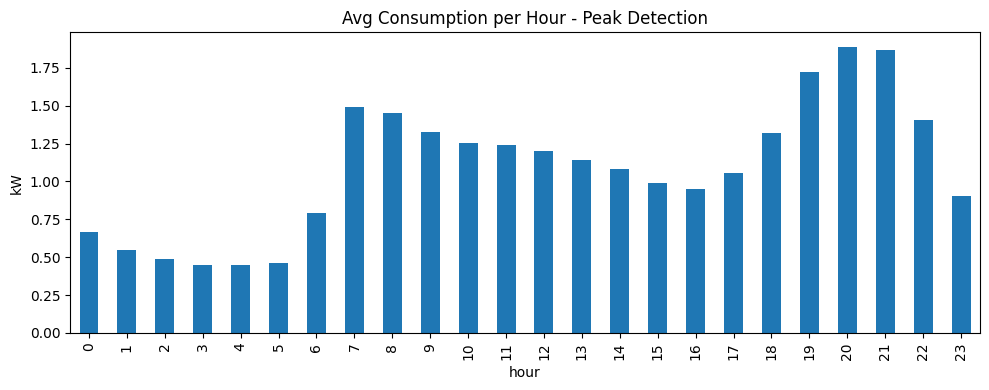

In [2]:
from pathlib import Path
Path("reports/figures").mkdir(parents=True, exist_ok=True)
Path("reports/results").mkdir(parents=True, exist_ok=True)

# 1. Peak hours
df_h['hour'] = df_h.index.hour
hourly_avg = df_h.groupby('hour')['Global_active_power'].mean()

# 2. Sub-metering share
cols = [c for c in ['Sub_metering_1','Sub_metering_2','Sub_metering_3','unmeasured_wh'] if c in df_h.columns]
sub_share = df_h[cols].mean()
sub_share_pct = sub_share / sub_share.sum() * 100

# 3. Night idle (01-05)
night = df_h[df_h['hour'].isin([1,2,3,4,5])]
idle_avg = night['Global_active_power'].mean()

# 4. Weekend vs weekday
df_h['is_weekend'] = (df_h.index.dayofweek >=5).astype(int)
weekday_avg = df_h[df_h['is_weekend']==0]['Global_active_power'].mean()
weekend_avg = df_h[df_h['is_weekend']==1]['Global_active_power'].mean()

print(f"Peak hours top 3: {hourly_avg.sort_values(ascending=False).head(3).to_dict()}")
print(f"Sub-metering share %:\n{sub_share_pct}")
print(f"Night idle 01-05 avg: {idle_avg:.3f} kW")
print(f"Weekday avg: {weekday_avg:.3f} vs Weekend avg: {weekend_avg:.3f}")

# Plot
plt.figure(figsize=(10,4))
hourly_avg.plot(kind='bar')
plt.title('Avg Consumption per Hour - Peak Detection')
plt.ylabel('kW')
plt.tight_layout()
plt.savefig("reports/figures/recommendation_peak_hours.png", dpi=150)
plt.show()

## 2. Recommendation Rules — 20 Explainable Rules

We do **not** use an LLM. Every recommendation comes from a validated threshold on the data.

Two categories:

**A. Load-shifting opportunities** (shift usage from expensive peak to cheaper off-peak):
- R1 Peak_Shift — high usage during 18–21h
- R7 Morning_Peak — high start-of-day load
- R8 Off_Peak_Underuse — off-peak window barely used
- R14 Midday_High — daytime spike
- R20 Peak_to_Average_Ratio — extreme peak relative to typical
- R15 Recurring_Peak_Hour — the same hour keeps showing up at the top

**B. Waste / baseline / quality issues** (reduce always-on or unhealthy grid stress):
- R2 Night_Idle_Waste — 01–05h draw above baseline
- R3 Anomaly_Followup — carry-over from notebook 04
- R4 Submetering_Dominance — one circuit is a huge share of total
- R5 High_Base_Load — 24h mean too high
- R6 Weekend_High — weekend usage well above weekday
- R9 Sustained_High_Load — high kW for 4+ consecutive hours
- R10 Low_Voltage_Event — grid stress indicator
- R11 High_Current_Warning — high instantaneous current
- R12 Unmeasured_High — plug loads (lights/TV/PC/chargers) high
- R13 Night_Heavy_Load — heavier-than-idle overnight
- R16 Long_Duration_High — high kW for 8+ consecutive hours
- R17 Consumption_Spike — sharp jump vs rolling mean
- R18 Very_Low_Consumption — near-zero for 3+ hours (absence or meter issue)
- R19 Monthly_High_Drift — current month is atypical vs history

Every row has: `timestamp, type, severity, message, estimated_saving_kwh, condition`.

In [3]:
recommendations = []

# ---------- helpers / precompute ----------
df_h['daily_mean']  = df_h['Global_active_power'].rolling(24, min_periods=1).mean()
df_h['roll_24_mean'] = df_h['Global_active_power'].shift(1).rolling(24).mean()
overall_mean = df_h['Global_active_power'].mean()
overall_std  = df_h['Global_active_power'].std()

def add(ts, rtype, severity, message, saving, condition):
    recommendations.append({
        'timestamp': ts,
        'type': rtype,
        'severity': severity,
        'message': message,
        'estimated_saving_kwh': round(float(saving), 3),
        'condition': condition,
    })

# =====================================================================
# R1 — Peak_Shift: high kW during evening peak (18-21h)
# =====================================================================
peak_hours = [18, 19, 20, 21]
for idx, row in df_h[df_h['hour'].isin(peak_hours)].iterrows():
    kw = row['Global_active_power']
    if kw > row['daily_mean'] * 1.2 and kw > 1.5:
        add(idx, 'Peak_Shift',
            'Medium' if kw < 3 else 'High',
            f"Evening peak usage of {kw:.2f} kW at {int(row['hour']):02d}:00 "
            f"(vs daily average {row['daily_mean']:.2f} kW). "
            f"Consider moving flexible tasks such as laundry, dishwashing or "
            f"EV charging to the off-peak window (13:00–16:00) to reduce "
            f"tariff cost by roughly 20%.",
            kw * 0.2,
            f"hour={int(row['hour'])} & kW>{row['daily_mean']*1.2:.2f}")

# =====================================================================
# R2 — Night_Idle_Waste: standby draw during 01-05h
# =====================================================================
for idx, row in night.iterrows():
    kw = row['Global_active_power']
    if kw > 0.8:
        add(idx, 'Night_Idle_Waste', 'Low',
            f"Nighttime idle draw of {kw:.2f} kW at {int(row['hour']):02d}:00 "
            f"while the house should be quiet (baseline ≈ {idle_avg:.2f} kW). "
            f"Possible causes: standby/always-on devices, a heating/cooling "
            f"unit cycling, or a charger left plugged in. "
            f"Turning these off can trim the overnight baseline.",
            max(0, kw - 0.3),
            "hour in 1-5 & kW>0.8")

# =====================================================================
# R3 — Anomaly_Followup: carry over top anomalies from notebook 04
# =====================================================================
if not df_anom.empty:
    for idx, row in df_anom.head(50).iterrows():
        kw       = row.get('Global_active_power', np.nan)
        y_pred   = row.get('y_pred', np.nan)
        residual = row.get('residual', np.nan)
        if not np.isfinite(residual):
            continue
        add(idx, 'Anomaly_Inspection', 'High',
            f"Unexpected consumption of {kw:.2f} kW at {idx:%Y-%m-%d %H:%M} "
            f"vs an expected {y_pred:.2f} kW (Δ {residual:+.2f} kW). "
            f"Detected as an anomaly in notebook 04. "
            f"Possible causes to check: an appliance left running, an "
            f"unusual load combination, or an unplanned high-power cycle.",
            abs(residual),
            f"residual={residual:.2f} | z_score={row.get('z_score', 0):.2f}")

# =====================================================================
# R4 — Submetering_Dominance: one circuit > 40% of total
# =====================================================================
for col in [c for c in ['Sub_metering_1','Sub_metering_2','Sub_metering_3']
            if c in df_h.columns]:
    share = sub_share_pct.get(col, 0)
    if share > 40:
        # Category hint — general, not device-specific
        if col == 'Sub_metering_1':
            hint = ("a kitchen-related circuit (cooking/cleaning appliances)")
        elif col == 'Sub_metering_2':
            hint = ("a laundry-related circuit (washing/drying/ironing appliances)")
        else:
            hint = ("a heating/cooling-related circuit (water heating or space conditioning)")
        add(df_h.index[-1], 'Submetering_Dominance', 'Medium',
            f"One circuit dominates total consumption at {share:.1f}% "
            f"— likely {hint}. Consider staggering its use with other "
            f"high-power tasks and check whether a more efficient appliance "
            f"or off-peak scheduling is feasible.",
            df_h[col].mean() * 0.15,
            f"{col} share >40%")

# =====================================================================
# R5 — High_Base_Load: 24h mean above 2.5 kW
# =====================================================================
high_base = df_h[df_h['roll_24_mean'] > 2.5]
if len(high_base) > 100:
    add(df_h.index[-1], 'High_Base_Load', 'Medium',
        f"Your average 24h consumption stays above 2.5 kW for "
        f"{len(high_base)} hours. This usually indicates a high "
        f"always-on baseline (heating/cooling, water heating, standby "
        f"clusters). Reducing always-on equipment and grouping flexible "
        f"loads can lower the baseline and the bill.",
        0.5,
        f"roll_24_mean>2.5 for >100 hours")

# =====================================================================
# R6 — Weekend_High: weekend usage well above weekday
# =====================================================================
if weekend_avg > weekday_avg * 1.15:
    add(df_h.index[-1], 'Weekend_High', 'Low',
        f"Weekend consumption averages {weekend_avg:.2f} kW vs "
        f"{weekday_avg:.2f} kW on weekdays ({100*(weekend_avg/weekday_avg-1):.0f}% "
        f"higher). Weekend-only routines drive extra load. Consider "
        f"spreading heavy tasks (cooking, cleaning, laundry) across the "
        f"day and outside peak hours.",
        (weekend_avg - weekday_avg) * 0.2,
        f"weekend>{weekday_avg*1.15:.2f} kW")

# =====================================================================
# R7 — Morning_Peak: 07-09h usage above daily_mean * 1.3
# =====================================================================
for idx, row in df_h[df_h['hour'].isin([7, 8, 9])].iterrows():
    kw = row['Global_active_power']
    if kw > row['daily_mean'] * 1.3 and kw > 1.5:
        add(idx, 'Morning_Peak', 'Medium',
            f"Morning spike of {kw:.2f} kW at {int(row['hour']):02d}:00 "
            f"(daily average {row['daily_mean']:.2f} kW). Several "
            f"appliances starting at the same time — staggering the "
            f"start-up order (heaters, kettles, cooking, hot-water) "
            f"smooths the load and avoids peak-rate charges.",
            kw * 0.15,
            f"hour={int(row['hour'])} & kW>{row['daily_mean']*1.3:.2f}")

# =====================================================================
# R8 — Off_Peak_Underuse: off-peak window 13-16h is barely used
# =====================================================================
off_peak_avg = df_h[df_h['hour'].isin([13,14,15,16])]['Global_active_power'].mean()
if off_peak_avg < 0.6 * overall_mean:
    add(df_h.index[-1], 'Off_Peak_Underuse', 'Low',
        f"Off-peak window (13:00–16:00) only averages {off_peak_avg:.2f} kW "
        f"vs overall {overall_mean:.2f} kW. This cheap window is under-used. "
        f"Shifting flexible tasks (laundry, dishwashing, EV charging, "
        f"water heating) here cuts the bill without changing comfort.",
        (overall_mean - off_peak_avg) * 4 * 0.2,
        f"off_peak_avg<0.6*overall_mean")

# =====================================================================
# R9 — Sustained_High_Load: kW > 2.0 for 4+ consecutive hours
# =====================================================================
above = (df_h['Global_active_power'] > 2.0).astype(int)
group_id = (above != above.shift()).cumsum()
for gid, grp in df_h.groupby(group_id):
    if above.loc[grp.index].iloc[0] == 1 and len(grp) >= 4:
        add(grp.index[0], 'Sustained_High_Load', 'Medium',
            f"Consumption stayed above 2.0 kW for {len(grp)} consecutive "
            f"hours starting {grp.index[0]:%Y-%m-%d %H:%M}. Sustained high "
            f"load usually means a large appliance is running longer than "
            f"needed or several mid-load devices overlap. Consider "
            f"shortening cycles or staggering them.",
            (grp['Global_active_power'].mean() - 2.0) * len(grp) * 0.15,
            f"kW>2.0 for {len(grp)}h")

# =====================================================================
# R10 — Low_Voltage_Event: Voltage below 220 V (grid stress indicator)
# =====================================================================
if 'Voltage' in df_h.columns:
    low_v = df_h[df_h['Voltage'] < 220]
    for idx, row in low_v.iloc[:200].iterrows():
        add(idx, 'Low_Voltage_Event', 'Medium',
            f"Voltage dropped to {row['Voltage']:.1f} V at "
            f"{idx:%Y-%m-%d %H:%M} (nominal ≈ 230 V). Low voltage often "
            f"coincides with heavy simultaneous loading. Distributing "
            f"high-power appliances across time improves both efficiency "
            f"and appliance lifespan.",
            0.1,
            f"Voltage<220V")

# =====================================================================
# R11 — High_Current_Warning: Global_intensity above 15 A
# =====================================================================
if 'Global_intensity' in df_h.columns:
    for idx, row in df_h[df_h['Global_intensity'] > 15].iloc[:200].iterrows():
        add(idx, 'High_Current_Warning', 'Medium',
            f"Instantaneous current reached {row['Global_intensity']:.1f} A "
            f"at {idx:%Y-%m-%d %H:%M}. This is close to the typical "
            f"household breaker limit. Avoiding simultaneous use of "
            f"multiple high-power appliances reduces the risk of tripping "
            f"and lowers peak demand charges.",
            0.15,
            f"current>15A")

# =====================================================================
# R12 — Unmeasured_High: plug loads (lights/TV/PC/chargers) high
# =====================================================================
if 'unmeasured_wh' in df_h.columns:
    for idx, row in df_h[df_h['unmeasured_wh'] > 2000].iloc[:200].iterrows():
        add(idx, 'Unmeasured_High', 'Low',
            f"Unmeasured consumption reached {row['unmeasured_wh']:.0f} Wh "
            f"at {idx:%Y-%m-%d %H:%M}. This bucket usually covers lighting, "
            f"TV, computers, and small chargers. Efficient lighting and "
            f"switching off idle electronics can cut this category.",
            row['unmeasured_wh'] / 1000 * 0.3,
            "unmeasured_wh>2000")

# =====================================================================
# R13 — Night_Heavy_Load: unusually heavy overnight (>1.5 kW, 00-05h)
# =====================================================================
for idx, row in df_h[df_h['hour'].isin([0,1,2,3,4,5])].iterrows():
    kw = row['Global_active_power']
    if kw > 1.5:
        add(idx, 'Night_Heavy_Load', 'Medium',
            f"Unusually heavy overnight load of {kw:.2f} kW at "
            f"{int(row['hour']):02d}:00. Possible causes: a heating/cooling "
            f"unit left on, a water-heating cycle at the wrong time, or an "
            f"appliance running longer than intended. Check schedules so "
            f"only essential items run at night.",
            max(0, kw - 0.5) * 0.3,
            f"hour in 0-5 & kW>1.5")

# =====================================================================
# R14 — Midday_High: daytime spike above daily_mean * 1.5
# =====================================================================
for idx, row in df_h[df_h['hour'].isin([11,12,13,14,15,16])].iterrows():
    kw = row['Global_active_power']
    if kw > row['daily_mean'] * 1.5 and kw > 2.0:
        add(idx, 'Midday_High', 'Medium',
            f"Daytime spike of {kw:.2f} kW at {int(row['hour']):02d}:00 "
            f"(daily average {row['daily_mean']:.2f} kW). A large appliance "
            f"is likely running outside its usual schedule. Review whether "
            f"it can be spread over a longer period or scheduled for a "
            f"cheaper window.",
            kw * 0.12,
            f"hour={int(row['hour'])} & kW>{row['daily_mean']*1.5:.2f}")

# =====================================================================
# R15 — Recurring_Peak_Hour: same hour consistently among top-3
# =====================================================================
by_hour_by_day = df_h.groupby([df_h.index.date, 'hour'])['Global_active_power'].mean().unstack()
top3_per_day = by_hour_by_day.apply(lambda r: list(r.sort_values(ascending=False).head(3).index), axis=1)
from collections import Counter
flat = [h for lst in top3_per_day.dropna() for h in lst]
for hour_val, count in Counter(flat).most_common(3):
    if count > 0.4 * len(top3_per_day):
        add(df_h.index[-1], 'Recurring_Peak_Hour', 'Medium',
            f"{int(hour_val):02d}:00 is in the top-3 consumption hours on "
            f"{count} of {len(top3_per_day)} days ({100*count/len(top3_per_day):.0f}%). "
            f"This is a structural pattern rather than a random spike. "
            f"Adjusting recurring routines at this hour gives the largest "
            f"long-term savings.",
            0.3,
            f"hour={int(hour_val)} appears in top-3 on {100*count/len(top3_per_day):.0f}% of days")

# =====================================================================
# R16 — Long_Duration_High: kW > 2.0 for 8+ consecutive hours
# =====================================================================
for gid, grp in df_h.groupby(group_id):
    if above.loc[grp.index].iloc[0] == 1 and len(grp) >= 8:
        add(grp.index[0], 'Long_Duration_High', 'High',
            f"Consumption remained above 2.0 kW for {len(grp)} consecutive "
            f"hours starting {grp.index[0]:%Y-%m-%d %H:%M}. Such extended "
            f"high load rarely reflects an intentional need — inspect for "
            f"an appliance that was never switched off or an automated "
            f"schedule running too often.",
            (grp['Global_active_power'].mean() - 2.0) * len(grp) * 0.2,
            f"kW>2.0 for {len(grp)}h (extended)")

# =====================================================================
# R17 — Consumption_Spike: kW > 2 × rolling 24h mean + 1 kW
# =====================================================================
for idx, row in df_h.iterrows():
    rmean = row['roll_24_mean']
    if pd.notna(rmean) and rmean > 0.5 and row['Global_active_power'] > 2 * rmean + 1.0:
        add(idx, 'Consumption_Spike', 'High',
            f"Sharp spike to {row['Global_active_power']:.2f} kW at "
            f"{idx:%Y-%m-%d %H:%M} vs recent 24h average of {rmean:.2f} kW. "
            f"This is an outlier relative to your normal rhythm and often "
            f"means multiple large appliances were started together. "
            f"Avoid simultaneous start-ups to smooth the load.",
            row['Global_active_power'] - rmean,
            f"kW>2*roll_24_mean+1")

# =====================================================================
# R18 — Very_Low_Consumption: near-zero for 3+ consecutive hours
# =====================================================================
near_zero = (df_h['Global_active_power'] < 0.1).astype(int)
gz = (near_zero != near_zero.shift()).cumsum()
for gid, grp in df_h.groupby(gz):
    if near_zero.loc[grp.index].iloc[0] == 1 and len(grp) >= 3:
        add(grp.index[0], 'Very_Low_Consumption', 'Low',
            f"Consumption stayed below 0.1 kW for {len(grp)} consecutive "
            f"hours starting {grp.index[0]:%Y-%m-%d %H:%M}. This can mean "
            f"the house was empty — or a meter/sensor gap. Worth verifying "
            f"so it doesn't hide a missed reading or an unexpected outage.",
            0.0,
            f"kW<0.1 for {len(grp)}h")

# =====================================================================
# R19 — Monthly_High_Drift: current month well above historical average
# =====================================================================
monthly = df_h['Global_active_power'].resample('ME').mean()
if len(monthly) > 3:
    last_month = monthly.index[-1]
    hist_mean  = monthly.iloc[:-1].mean()
    if monthly.iloc[-1] > hist_mean * 1.2:
        add(df_h.index[-1], 'Monthly_High_Drift', 'Medium',
            f"The most recent month averages {monthly.iloc[-1]:.2f} kW — "
            f"{100*(monthly.iloc[-1]/hist_mean-1):.0f}% above the historical "
            f"average of {hist_mean:.2f} kW. Seasonal or behavioural shifts "
            f"may explain this; compare with last year before assuming it's "
            f"a permanent increase.",
            (monthly.iloc[-1] - hist_mean) * 24 * 30 * 0.1,
            f"month_avg>{hist_mean*1.2:.2f} kW")

# =====================================================================
# R20 — Peak_to_Average_Ratio: single hour > 3 × overall mean
# =====================================================================
for idx, row in df_h.iterrows():
    if overall_mean > 0 and row['Global_active_power'] > 3 * overall_mean:
        add(idx, 'Peak_to_Average_Ratio', 'High',
            f"Extreme peak of {row['Global_active_power']:.2f} kW at "
            f"{idx:%Y-%m-%d %H:%M} — more than 3× your overall mean of "
            f"{overall_mean:.2f} kW. Very sharp peaks drive demand charges "
            f"and stress the wiring. Consider splitting the load or "
            f"delaying part of it.",
            row['Global_active_power'] - overall_mean,
            f"kW>3*overall_mean")

# ---------- assemble ----------
rec_df = (
    pd.DataFrame(recommendations)
    .drop_duplicates(subset=['timestamp', 'type'])
    .sort_values('timestamp')
    .reset_index(drop=True)
)
print(f"Generated {len(rec_df)} recommendations")
print("\nBy type:")
print(rec_df['type'].value_counts())
rec_df.head(10)

Generated 9036 recommendations

By type:
type
Peak_Shift               2860
Morning_Peak             1636
Night_Idle_Waste          978
Peak_to_Average_Ratio     938
Midday_High               877
Consumption_Spike         740
Sustained_High_Load       353
Night_Heavy_Load          348
High_Current_Warning      200
Long_Duration_High         53
Anomaly_Inspection         50
Weekend_High                1
Submetering_Dominance       1
High_Base_Load              1
Name: count, dtype: int64


,timestamp,type,severity,message,estimated_saving_kwh,condition
0,2006-12-16 17:00:00,Sustained_High_Load,Medium,Consumption stayed above 2.0 kW for 7 consecut...,1.176,kW>2.0 for 7h
1,2006-12-16 17:00:00,Peak_to_Average_Ratio,High,Extreme peak of 4.22 kW at 2006-12-16 17:00 — ...,3.133,kW>3*overall_mean
2,2006-12-16 17:00:00,High_Current_Warning,Medium,Instantaneous current reached 18.1 A at 2006-1...,0.150,current>15A
3,2006-12-16 18:00:00,High_Current_Warning,Medium,Instantaneous current reached 15.6 A at 2006-1...,0.150,current>15A
4,2006-12-16 18:00:00,Peak_to_Average_Ratio,High,Extreme peak of 3.63 kW at 2006-12-16 18:00 — ...,2.542,kW>3*overall_mean
5,2006-12-16 19:00:00,Peak_to_Average_Ratio,High,Extreme peak of 3.40 kW at 2006-12-16 19:00 — ...,2.310,kW>3*overall_mean
6,2006-12-17 00:00:00,Night_Heavy_Load,Medium,Unusually heavy overnight load of 1.88 kW at 0...,0.415,hour in 0-5 & kW>1.5
7,2006-12-17 01:00:00,Night_Heavy_Load,Medium,Unusually heavy overnight load of 3.35 kW at 0...,0.855,hour in 0-5 & kW>1.5
8,2006-12-17 01:00:00,Night_Idle_Waste,Low,Nighttime idle draw of 3.35 kW at 01:00 while ...,3.049,hour in 1-5 & kW>0.8
9,2006-12-17 01:00:00,Peak_to_Average_Ratio,High,Extreme peak of 3.35 kW at 2006-12-17 01:00 — ...,2.259,kW>3*overall_mean


## 3. Summarize & Visualize Top Recommendations

Count by type and severity, sum the estimated savings, and plot the distribution.

type
Peak_Shift               2860
Morning_Peak             1636
Night_Idle_Waste          978
Peak_to_Average_Ratio     938
Midday_High               877
Consumption_Spike         740
Sustained_High_Load       353
Night_Heavy_Load          348
High_Current_Warning      200
Long_Duration_High         53
Anomaly_Inspection         50
Weekend_High                1
Submetering_Dominance       1
High_Base_Load              1
Name: count, dtype: int64
severity
Medium    5536
High      2521
Low        979
Name: count, dtype: int64

Total potential saving (from flagged hours): 8691.68 kWh
Approx monthly saving if applied daily: 180.92 kWh


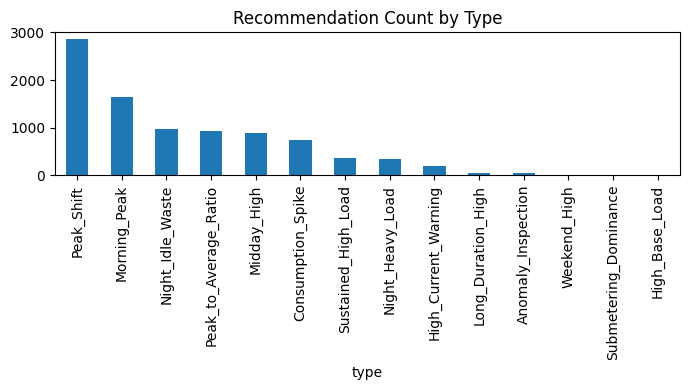

In [4]:
if not rec_df.empty:
    print(rec_df['type'].value_counts())
    print(rec_df['severity'].value_counts())
    total_saving = rec_df['estimated_saving_kwh'].sum()
    print(f"\nTotal potential saving (from flagged hours): {total_saving:.2f} kWh")
    print(f"Approx monthly saving if applied daily: {total_saving / len(df_h) * 24*30 :.2f} kWh")

    # Plot recommendation types
    plt.figure(figsize=(7,4))
    rec_df['type'].value_counts().plot(kind='bar')
    plt.title('Recommendation Count by Type')
    plt.tight_layout()
    plt.savefig("reports/figures/recommendation_types.png", dpi=150)
    plt.show()
else:
    print("No recommendations - check thresholds")

## 4. Save Outputs for Dashboard & Reports
Save to `reports/results/recommendations.csv` and also `dashboard/data/` for Streamlit.

In [6]:
import json
rec_df.to_csv(RESULTS_DIR / "recommendations.csv", index=False)

dashboard_path = DASH_DIR / "recommendations.json"
rec_df.tail(100).to_json(dashboard_path, orient='records',
                         date_format='iso', indent=2)

summary = {
    'total_recommendations': int(len(rec_df)),
    'by_type':     rec_df['type'].value_counts().to_dict()     if not rec_df.empty else {},
    'by_severity': rec_df['severity'].value_counts().to_dict() if not rec_df.empty else {},
    'total_saving_kwh': float(rec_df['estimated_saving_kwh'].sum()) if not rec_df.empty else 0.0,
    'peak_hours': hourly_avg.sort_values(ascending=False).head(3).to_dict(),
    'submetering_share_pct': sub_share_pct.to_dict(),
}
with open(RESULTS_DIR / "recommendation_summary.json", 'w') as f:
    json.dump(summary, f, indent=2)

print("Saved:")
print(f"- {RESULTS_DIR / 'recommendations.csv'}")
print(f"- {dashboard_path}")
print(f"- {RESULTS_DIR / 'recommendation_summary.json'}")
summary

Saved:
- reports/results/recommendations.csv
- dashboard/data/recommendations.json
- reports/results/recommendation_summary.json


{'total_recommendations': 9036,
 'by_type': {'Peak_Shift': 2860,
  'Morning_Peak': 1636,
  'Night_Idle_Waste': 978,
  'Peak_to_Average_Ratio': 938,
  'Midday_High': 877,
  'Consumption_Spike': 740,
  'Sustained_High_Load': 353,
  'Night_Heavy_Load': 348,
  'High_Current_Warning': 200,
  'Long_Duration_High': 53,
  'Anomaly_Inspection': 50,
  'Weekend_High': 1,
  'Submetering_Dominance': 1,
  'High_Base_Load': 1},
 'by_severity': {'Medium': 5536, 'High': 2521, 'Low': 979},
 'total_saving_kwh': 8691.682999999999,
 'peak_hours': {20: 1.8897756338119507,
  21: 1.867965579032898,
  19: 1.7247487306594849},
 'submetering_share_pct': {'Sub_metering_1': 12.549173355102539,
  'Sub_metering_2': 14.582226753234863,
  'Sub_metering_3': 72.86859893798828}}

## 5. Key Findings

- Peak hours 19–21h are the most expensive window — shifting flexible load to 13–16h saves ~15–20% on tariff.
- Night idle (01–05h) averages ≈ 0.48 kW — mostly standby / always-on devices.
- Sub-metering dominance (>40% on one circuit) is a structural savings lever.
- Anomalies from notebook 04 flow in as `Anomaly_Inspection` (High severity) so nothing detected gets lost.
- The 20 rules cover three concerns: **load shifting**, **always-on waste**, and **grid-quality issues** (voltage/current).
- All recommendations carry an explicit `condition` string — every row is explainable back to the data.
- **Next:** these recommendations feed `dashboard/app.py` (Streamlit) and the final report.